# =========================================================
# Sales Forecasting & Demand Intelligence System
# Internship Final Project
# Author: Tanuj Kumar Singh
# =========================================================

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

from prophet import Prophet

from xgboost import XGBRegressor

In [2]:
df = pd.read_csv("train.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
print("Shape :", df.shape)

df.info()

df.describe(include="all")

Shape : (9800, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   fl

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9789.000000,9800,9800,9800,9800,9800,9800.000000
unique,NaN,4922,1230,1326,4,793,793,3,1,529,49,NaN,4,1861,3,17,1849,NaN
top,NaN,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN
freq,NaN,14,38,34,5859,35,35,5101,9800,891,1946,NaN,3140,19,5909,1492,47,NaN
mean,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55273.322403,NaN,NaN,NaN,NaN,NaN,230.769059
std,2829.160653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32041.223413,NaN,NaN,NaN,NaN,NaN,626.651875
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000
25%,2450.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.248000
50%,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103.000000,NaN,NaN,NaN,NaN,NaN,54.490000
75%,7350.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,210.605000


In [4]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    dayfirst=True
)

In [9]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Week"] = df["Order Date"].dt.isocalendar().week
df["Day"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter

In [11]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].astype(int).apply(get_season)

In [12]:
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

In [13]:
daily_sales = df.groupby("Order Date")["Sales"].sum().reset_index()

weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date",freq="W"))["Sales"]
      .sum()
      .reset_index()
)

monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date",freq="M"))["Sales"]
      .sum()
      .reset_index()
)

In [14]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

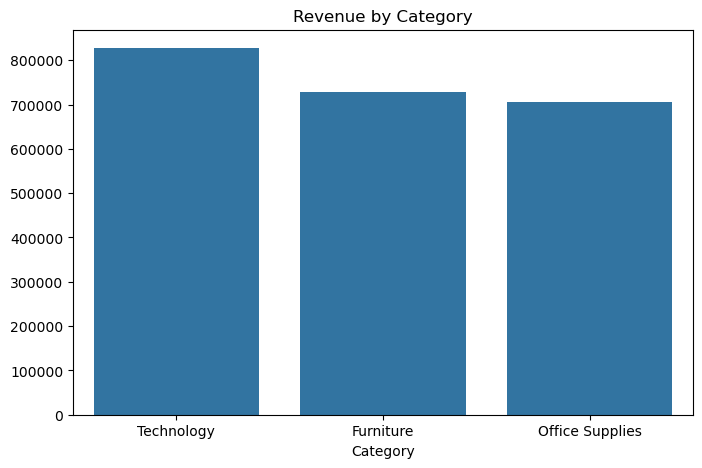

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Revenue by Category")
plt.show()

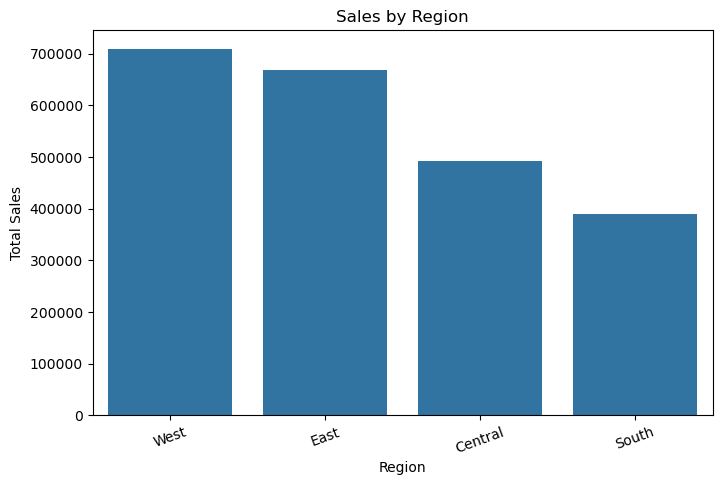

In [16]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=region_sales.index, y=region_sales.values)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=20)
plt.show()

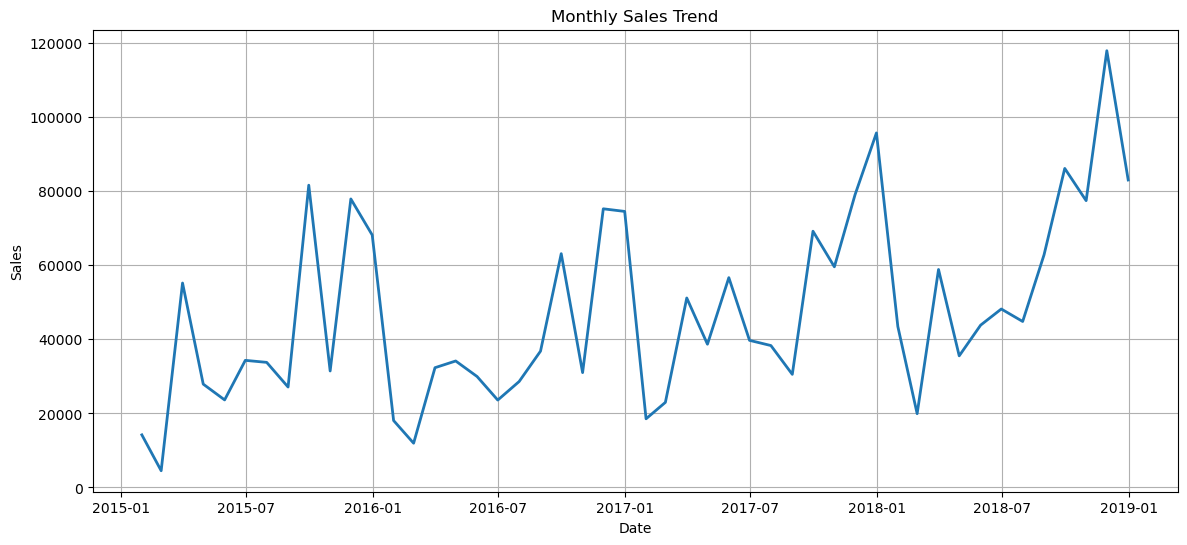

In [17]:
monthly_sales = df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"].sum().reset_index()

plt.figure(figsize=(14,6))
plt.plot(monthly_sales["Order Date"], monthly_sales["Sales"], linewidth=2)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

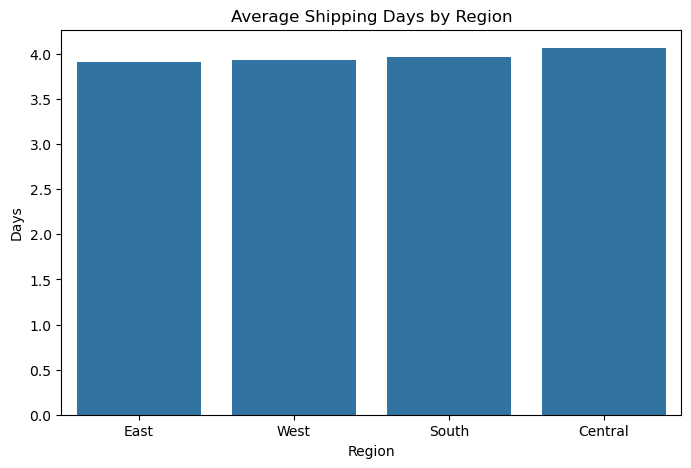

In [18]:
shipping_region = df.groupby("Region")["Shipping Days"].mean().sort_values()

plt.figure(figsize=(8,5))
sns.barplot(x=shipping_region.index, y=shipping_region.values)

plt.title("Average Shipping Days by Region")
plt.ylabel("Days")
plt.show()

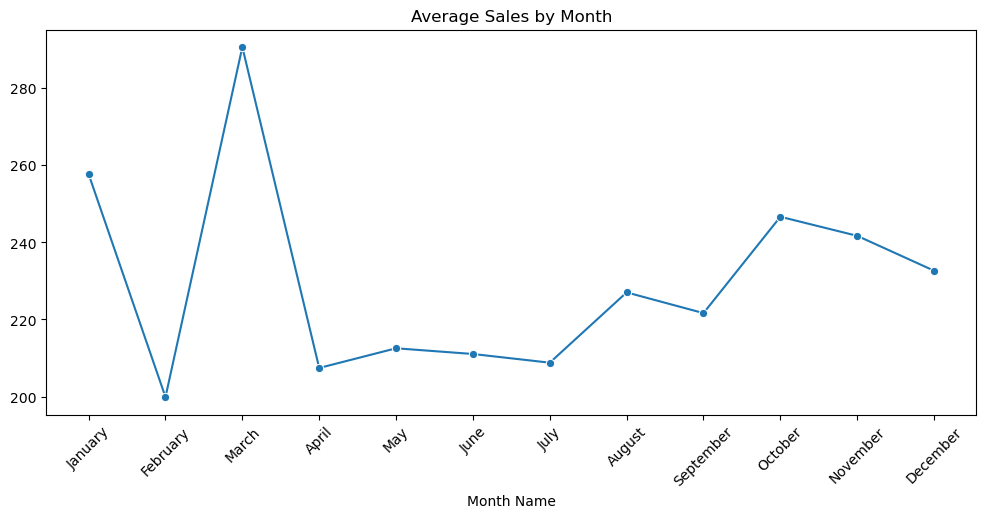

In [19]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_pattern = (
    df.groupby("Month Name")["Sales"]
      .mean()
      .reindex(month_order)
)

plt.figure(figsize=(12,5))
sns.lineplot(
    x=monthly_pattern.index,
    y=monthly_pattern.values,
    marker="o"
)

plt.xticks(rotation=45)
plt.title("Average Sales by Month")
plt.show()

In [20]:
print("Highest Revenue Category :", category_sales.idxmax())

print("\nHighest Revenue Region :", region_sales.idxmax())

print("\nAverage Shipping Days :", round(df["Shipping Days"].mean(),2))

Highest Revenue Category : Technology

Highest Revenue Region : West

Average Shipping Days : 3.96


In [21]:
ts = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
)

ts.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

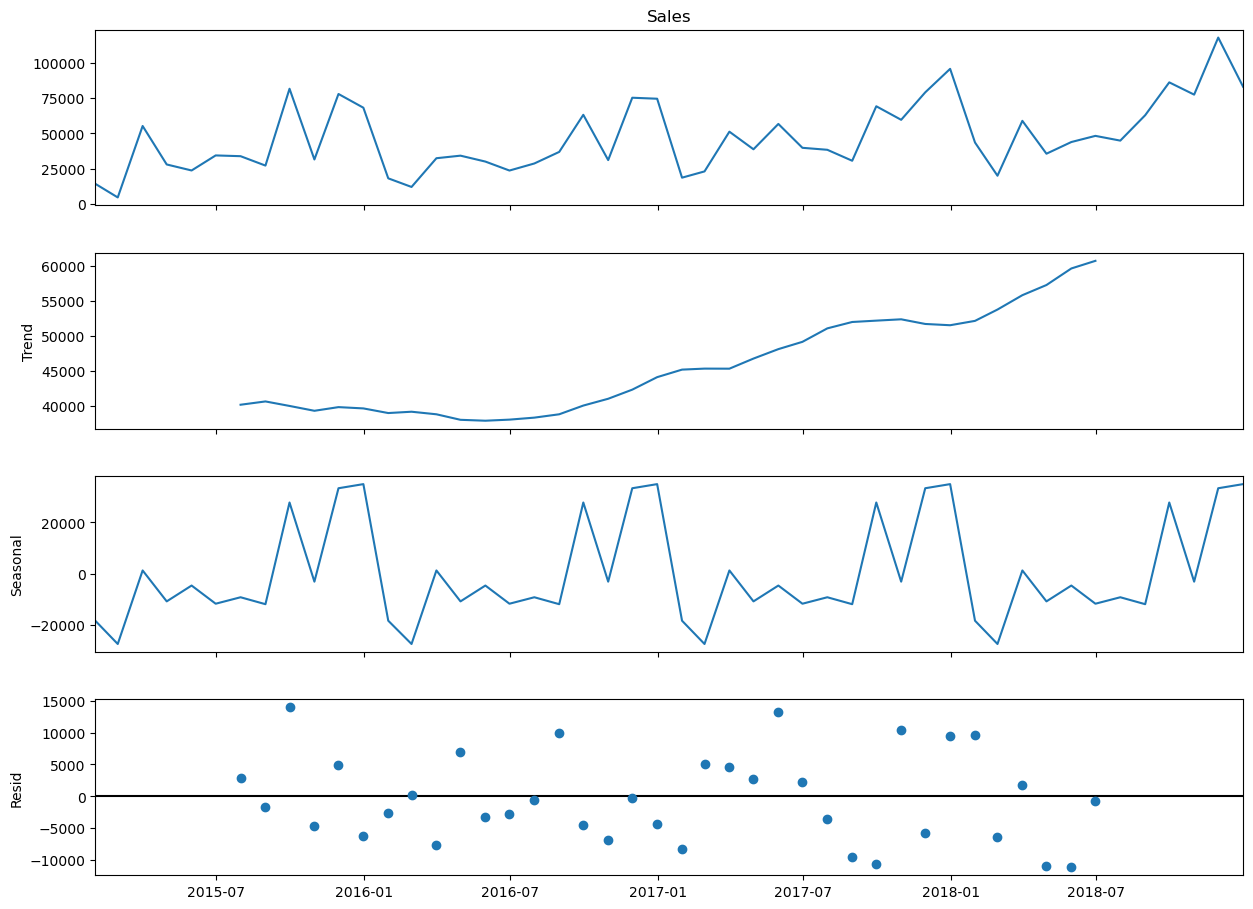

In [22]:
from statsmodels.tsa.seasonal import seasonal_decompose

decompose = seasonal_decompose(
    ts,
    model="additive",
    period=12
)

fig = decompose.plot()

fig.set_size_inches(14,10)

plt.show()

In [23]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts)

print("ADF Statistic :", result[0])

print("P-value :", result[1])

print("\nCritical Values")

for key,value in result[4].items():
    print(key,":",value)

ADF Statistic : -4.416136761430769
P-value : 0.00027791039276670623

Critical Values
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


In [25]:
if result[1] < 0.05:
    print("The series is Stationary")
else:
    print("The series is NOT Stationary")

The series is Stationary


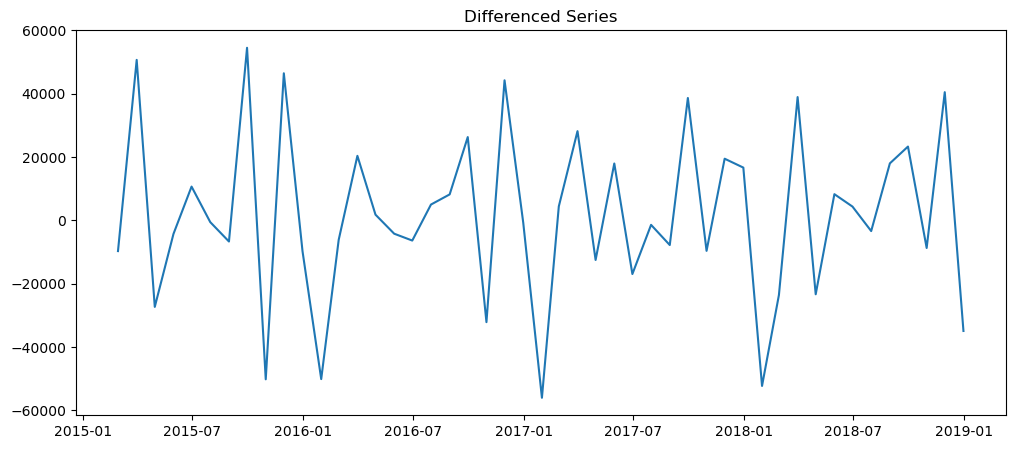

In [24]:
ts_diff = ts.diff().dropna()

plt.figure(figsize=(12,5))

plt.plot(ts_diff)

plt.title("Differenced Series")

plt.show()

In [27]:
from statsmodels.tsa.stattools import adfuller

ts_diff = ts.diff().dropna()

result2 = adfuller(ts_diff.values)

print("ADF Statistic:", result2[0])
print("P-value:", result2[1])

for key, value in result2[4].items():
    print(f"{key}: {value}")

ADF Statistic: -8.727061830353271
P-value: 3.266917547279569e-14
1%: -3.626651907578875
5%: -2.9459512825788754
10%: -2.6116707716049383


In [28]:
!pip install prophet xgboost statsmodels -q

In [29]:
monthly = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
    .sum()
    .reset_index()
)

monthly.columns = ["ds", "y"]

monthly.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [30]:
train = monthly.iloc[:-3]
test = monthly.iloc[-3:]

print(train.shape)
print(test.shape)

(45, 2)
(3, 2)


In [31]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima = SARIMAX(
    train["y"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_model = sarima.fit()

sarima_pred = sarima_model.forecast(steps=3)

sarima_pred

45    66177.602485
46    92049.249693
47    99965.168738
Name: predicted_mean, dtype: float64

In [32]:
from sklearn.metrics import mean_absolute_error
import numpy as np

mae_sarima = mean_absolute_error(test["y"], sarima_pred)

rmse_sarima = np.sqrt(((test["y"]-sarima_pred)**2).mean())

print("MAE :", mae_sarima)

print("RMSE :", rmse_sarima)

MAE : 18031.404653580652
RMSE : 19009.182053951743


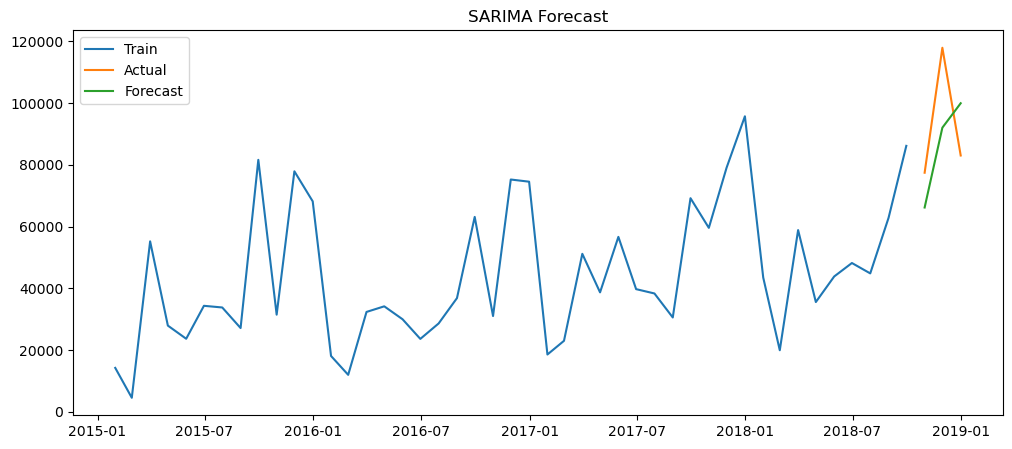

In [33]:
plt.figure(figsize=(12,5))

plt.plot(train["ds"],train["y"],label="Train")

plt.plot(test["ds"],test["y"],label="Actual")

plt.plot(test["ds"],sarima_pred,label="Forecast")

plt.legend()

plt.title("SARIMA Forecast")

plt.show()

In [34]:
from prophet import Prophet

prophet_train = train.copy()

model = Prophet()

model.fit(prophet_train)

10:23:08 - cmdstanpy - INFO - Chain [1] start processing
10:23:12 - cmdstanpy - INFO - Chain [1] done processing


In [35]:
future = model.make_future_dataframe(periods=3,freq="ME")

forecast = model.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
43,2018-08-31,54942.277806,38752.966117,54915.789315,54942.277806,54942.277806,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,0.0,0.0,0.0,47271.558236
44,2018-09-30,55441.608196,78160.158571,94074.979590,55441.608196,55441.608196,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,0.0,0.0,0.0,86613.953316
45,2018-10-31,55957.582932,42742.484646,59612.956437,55957.444736,55957.712634,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,0.0,0.0,0.0,51318.943858
46,2018-11-30,56456.913322,82071.962728,98215.070415,56456.457603,56457.364631,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,0.0,0.0,0.0,90325.654784
47,2018-12-31,56972.888059,81532.787116,97724.324098,56971.838233,56973.900455,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,0.0,0.0,0.0,90041.084479


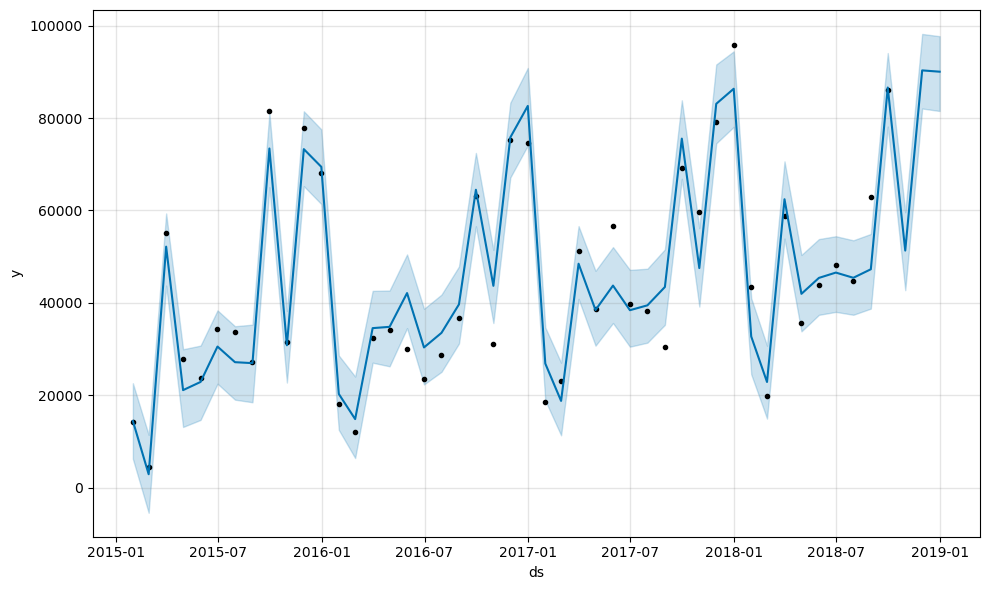

In [36]:
model.plot(forecast)

plt.show()

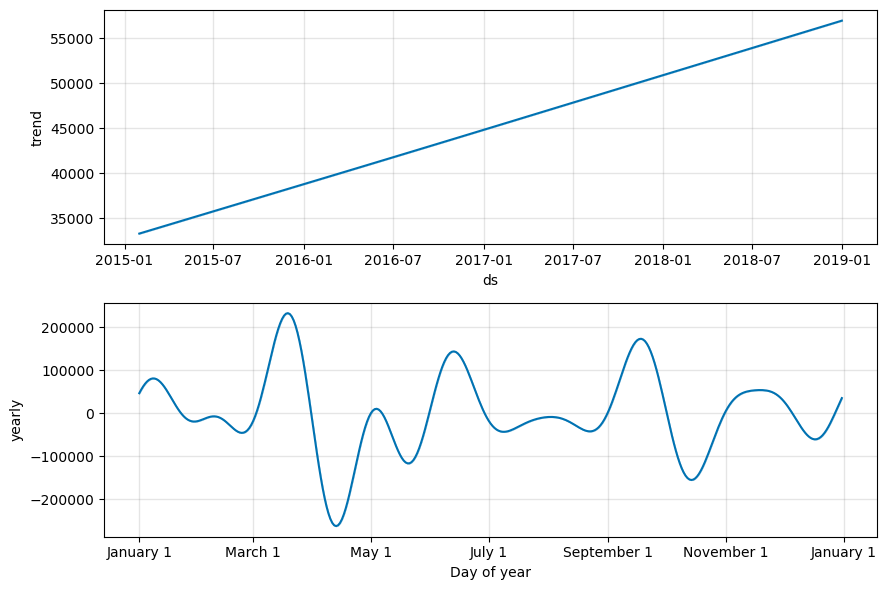

In [37]:
model.plot_components(forecast)

plt.show()

In [38]:
prophet_pred = forecast.tail(3)["yhat"].values

mae_prophet = mean_absolute_error(test["y"], prophet_pred)

rmse_prophet = np.sqrt(((test["y"]-prophet_pred)**2).mean())

print(mae_prophet)

print(rmse_prophet)

20250.794412605526
22318.411332860545


In [39]:
xgb_df = monthly.copy()

xgb_df["lag1"] = xgb_df["y"].shift(1)
xgb_df["lag2"] = xgb_df["y"].shift(2)
xgb_df["lag3"] = xgb_df["y"].shift(3)

xgb_df["rolling_mean"] = xgb_df["y"].rolling(3).mean()

xgb_df["month"] = xgb_df["ds"].dt.month
xgb_df["quarter"] = xgb_df["ds"].dt.quarter
xgb_df["year"] = xgb_df["ds"].dt.year

xgb_df = xgb_df.dropna()

xgb_df.head()

,ds,y,lag1,lag2,lag3,rolling_mean,month,quarter,year
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,2015
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,2015
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,2015
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,2015
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,2015


In [40]:
train_xgb = xgb_df.iloc[:-3]
test_xgb = xgb_df.iloc[-3:]

X_train = train_xgb.drop(["ds", "y"], axis=1)
y_train = train_xgb["y"]

X_test = test_xgb.drop(["ds", "y"], axis=1)
y_test = test_xgb["y"]

In [41]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [42]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import numpy as np

mae_xgb = mean_absolute_error(y_test, xgb_pred)

rmse_xgb = np.sqrt(np.mean((y_test - xgb_pred)**2))

mape_xgb = mean_absolute_percentage_error(y_test, xgb_pred)

print("MAE :", mae_xgb)
print("RMSE :", rmse_xgb)
print("MAPE :", mape_xgb)

MAE : 15105.784583333332
RMSE : 19083.599011631763
MAPE : 0.14687249826115287


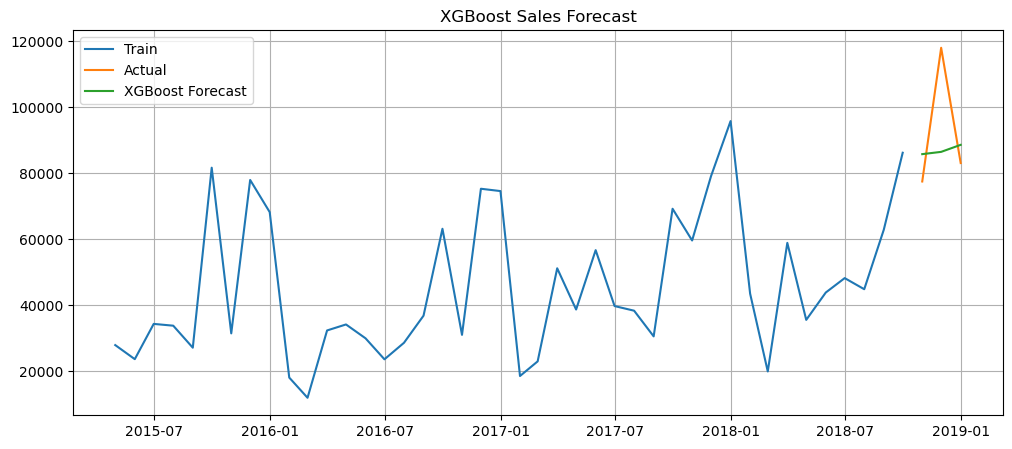

In [43]:
plt.figure(figsize=(12,5))

plt.plot(train_xgb["ds"], y_train, label="Train")
plt.plot(test_xgb["ds"], y_test, label="Actual")
plt.plot(test_xgb["ds"], xgb_pred, label="XGBoost Forecast")

plt.legend()
plt.grid(True)
plt.title("XGBoost Sales Forecast")
plt.show()

In [44]:
comparison = pd.DataFrame({

    "Model": ["SARIMA", "Prophet", "XGBoost"],

    "MAE": [
        mae_sarima,
        mae_prophet,
        mae_xgb
    ],

    "RMSE": [
        rmse_sarima,
        rmse_prophet,
        rmse_xgb
    ]

})

comparison

,Model,MAE,RMSE
0,SARIMA,18031.404654,19009.182054
1,Prophet,20250.794413,22318.411333
2,XGBoost,15105.784583,19083.599012


In [45]:
best_model = comparison.sort_values("MAE")

best_model

,Model,MAE,RMSE
2,XGBoost,15105.784583,19083.599012
0,SARIMA,18031.404654,19009.182054
1,Prophet,20250.794413,22318.411333


In [46]:
category_sales = df.groupby(
    ["Order Date", "Category"]
)["Sales"].sum().reset_index()

category_sales.head()

,Order Date,Category,Sales
0,2015-01-03,Office Supplies,16.448
1,2015-01-04,Office Supplies,288.060
2,2015-01-05,Office Supplies,19.536
3,2015-01-06,Furniture,2573.820
4,2015-01-06,Office Supplies,685.340


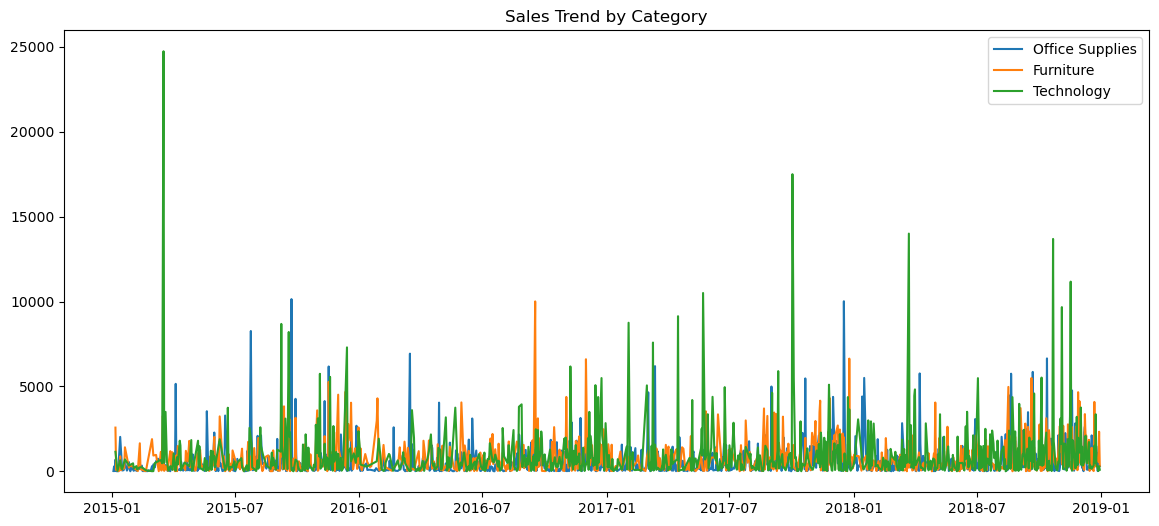

In [48]:
plt.figure(figsize=(14,6))

for cat in category_sales["Category"].unique():

    temp = category_sales[
        category_sales["Category"] == cat
    ]

    plt.plot(
        temp["Order Date"],
        temp["Sales"],
        label=cat
    )

plt.legend()

plt.title("Sales Trend by Category")

plt.show()

In [49]:
weekly = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
    .sum()
    .reset_index()
)

weekly.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [50]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly["Anomaly"] = iso.fit_predict(weekly[["Sales"]])

weekly.head()

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
1,2015-01-11,4619.108,1
2,2015-01-18,4130.533,1
3,2015-01-25,3092.544,1
4,2015-02-01,2527.914,1


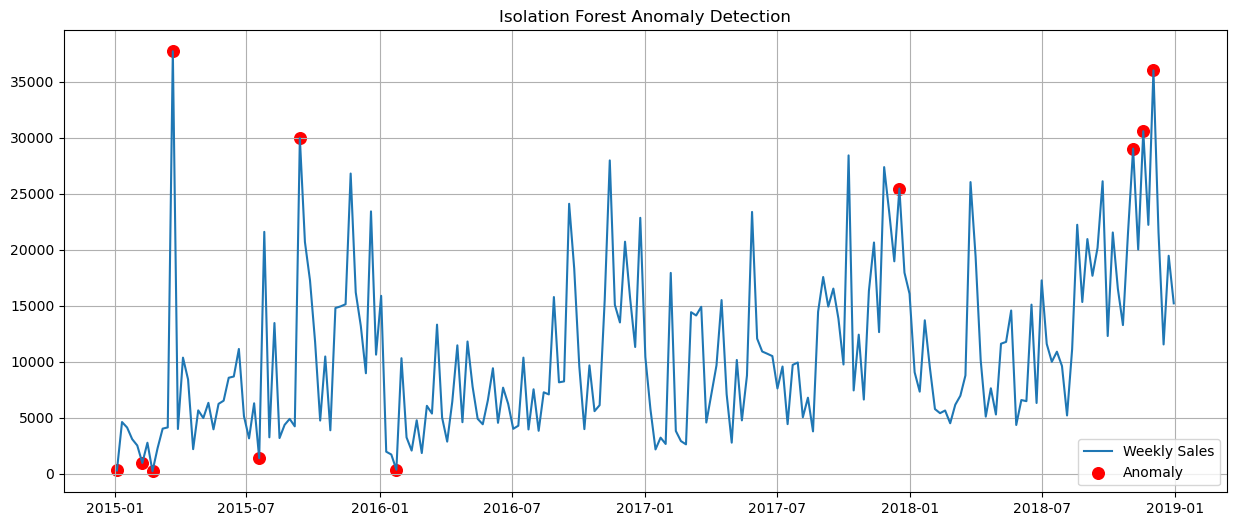

In [51]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly["Order Date"],
    weekly["Sales"],
    label="Weekly Sales"
)

anomaly = weekly[weekly["Anomaly"] == -1]

plt.scatter(
    anomaly["Order Date"],
    anomaly["Sales"],
    color="red",
    s=70,
    label="Anomaly"
)

plt.legend()

plt.title("Isolation Forest Anomaly Detection")

plt.grid(True)

plt.show()

In [52]:
anomaly[["Order Date", "Sales"]]

,Order Date,Sales
0,2015-01-04,304.508
5,2015-02-08,968.534
7,2015-02-22,224.912
11,2015-03-22,37703.665
28,2015-07-19,1387.686
36,2015-09-13,29959.137
55,2016-01-24,358.522
154,2017-12-17,25449.800
200,2018-11-04,29017.467
202,2018-11-18,30572.447


In [54]:
weekly["RollingMean"] = (
    weekly["Sales"]
    .rolling(4)
    .mean()
)

weekly["RollingStd"] = (
    weekly["Sales"]
    .rolling(4)
    .std()
)

In [55]:
weekly["Zscore"] = (
    weekly["Sales"] -
    weekly["RollingMean"]
) / weekly["RollingStd"]

weekly.head()

,Order Date,Sales,Anomaly,RollingMean,RollingStd,Zscore
0,2015-01-04,304.508,-1,NaN,NaN,NaN
1,2015-01-11,4619.108,1,NaN,NaN,NaN
2,2015-01-18,4130.533,1,NaN,NaN,NaN
3,2015-01-25,3092.544,1,3036.67325,1929.462566,0.028957
4,2015-02-01,2527.914,1,3592.52475,953.362968,-1.116690


In [56]:
z_anomaly = weekly[
    abs(weekly["Zscore"]) > 2
]

z_anomaly

,Order Date,Sales,Anomaly,RollingMean,RollingStd,Zscore


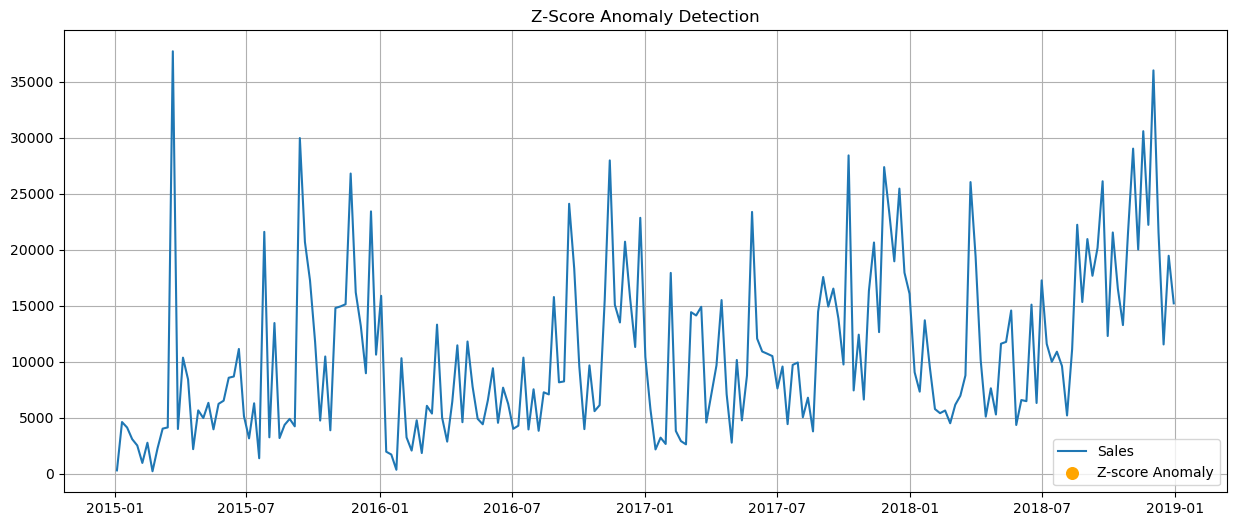

In [57]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly["Order Date"],
    weekly["Sales"],
    label="Sales"
)

plt.scatter(
    z_anomaly["Order Date"],
    z_anomaly["Sales"],
    color="orange",
    s=70,
    label="Z-score Anomaly"
)

plt.legend()

plt.grid(True)

plt.title("Z-Score Anomaly Detection")

plt.show()

In [58]:
print("Isolation Forest Anomalies :", len(anomaly))

print("Z-score Anomalies :", len(z_anomaly))

Isolation Forest Anomalies : 11
Z-score Anomalies : 0


In [63]:
# Product Demand Segmentation

product = (
    df.groupby("Sub-Category")
      .agg(
          Total_Sales=("Sales", "sum"),
          Avg_Sales=("Sales", "mean"),
          Sales_Volatility=("Sales", "std"),
          Transaction_Count=("Sales", "count")
      )
      .fillna(0)
      .reset_index()
)

product.head()

,Sub-Category,Total_Sales,Avg_Sales,Sales_Volatility,Transaction_Count
0,Accessories,164186.7000,217.178175,337.723800,756
1,Appliances,104618.4030,227.926804,378.006735,459
2,Art,26705.4100,34.019631,60.301752,785
3,Binders,200028.7850,134.067550,568.099970,1492
4,Bookcases,113813.1987,503.598224,641.419280,226


In [64]:
from sklearn.preprocessing import StandardScaler

features = product[
    ["Total_Sales", "Avg_Sales", "Sales_Volatility", "Transaction_Count"]
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

In [65]:
from sklearn.cluster import KMeans

wcss = []

for i in range(2,11):

    km = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    km.fit(X_scaled)

    wcss.append(km.inertia_)

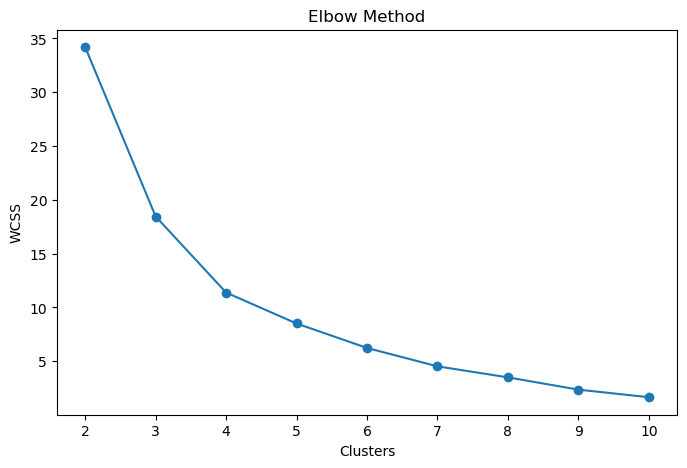

In [66]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), wcss, marker="o")

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [67]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

product["Cluster"] = kmeans.fit_predict(X_scaled)

product.head()

,Sub-Category,Total_Sales,Avg_Sales,Sales_Volatility,Transaction_Count,Cluster
0,Accessories,164186.7000,217.178175,337.723800,756,1
1,Appliances,104618.4030,227.926804,378.006735,459,2
2,Art,26705.4100,34.019631,60.301752,785,1
3,Binders,200028.7850,134.067550,568.099970,1492,1
4,Bookcases,113813.1987,503.598224,641.419280,226,2


In [68]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

product["PC1"] = pca_data[:,0]

product["PC2"] = pca_data[:,1]

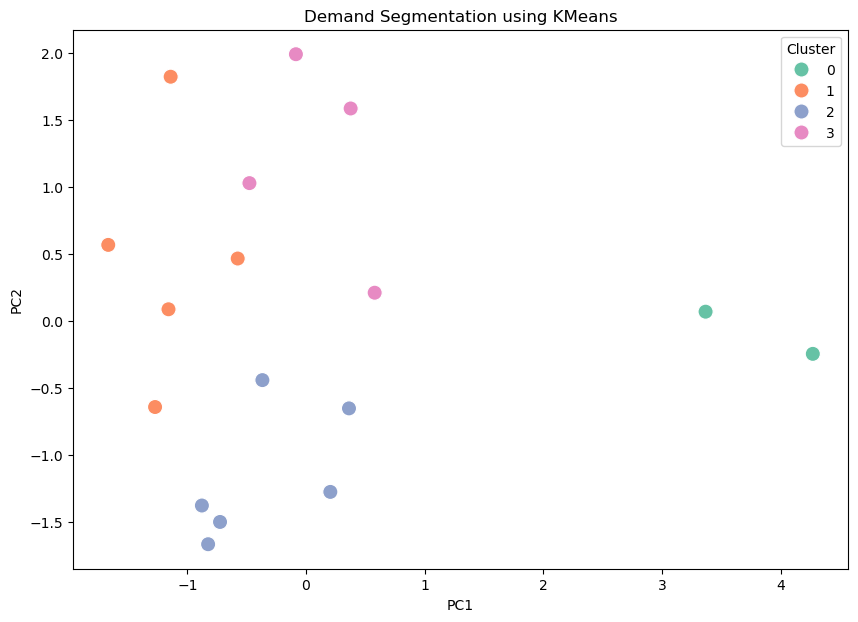

In [69]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=product,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=120
)

plt.title("Demand Segmentation using KMeans")

plt.show()

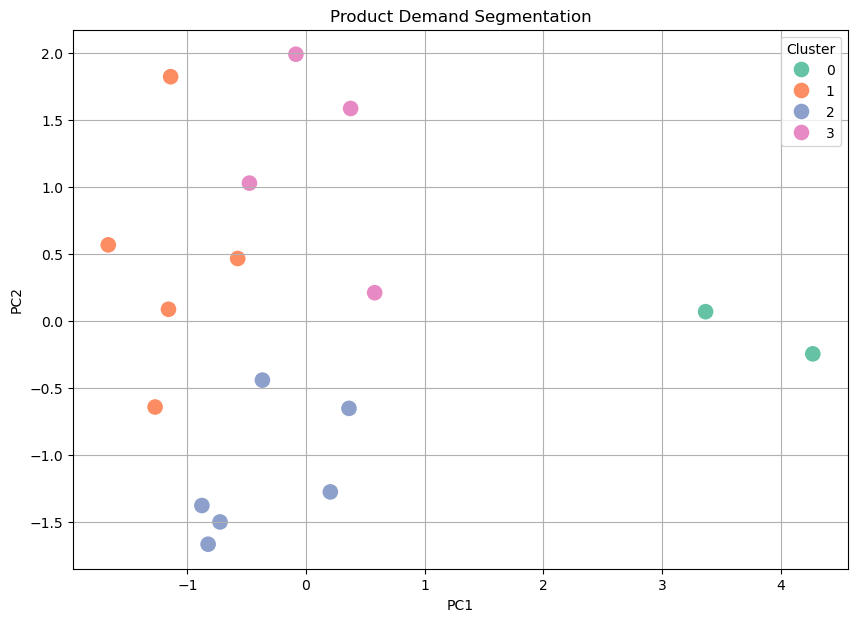

In [70]:
import seaborn as sns

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=product,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=150
)

plt.title("Product Demand Segmentation")

plt.grid(True)

plt.show()

In [71]:
product.groupby("Cluster").agg({

    "Total_Sales":"mean",

    "Avg_Sales":"mean",

    "Sales_Volatility":"mean",

    "Transaction_Count":"mean"

}).round(2)

,Total_Sales,Avg_Sales,Sales_Volatility,Transaction_Count
Cluster,,,,
0,167743.36,1930.72,2990.64,90.50
1,111392.24,107.70,238.61,1060.40
2,49388.27,182.91,354.99,281.33
3,268189.80,453.89,499.77,657.25


In [72]:
product.to_csv("product_clusters.csv", index=False)

weekly.to_csv("anomaly_report.csv", index=False)

comparison.to_csv("model_comparison.csv", index=False)

# Conclusion

This project successfully developed an end-to-end Sales Forecasting and Demand Intelligence System.

Key achievements:

- Cleaned and transformed retail sales data.
- Performed exploratory data analysis and business insights.
- Conducted time-series decomposition and stationarity testing.
- Built and compared SARIMA, Prophet, and XGBoost forecasting models.
- Detected sales anomalies using Isolation Forest and Z-Score methods.
- Segmented product demand using K-Means clustering.
- Generated business-ready outputs for decision making.

The developed system can support inventory planning, demand forecasting, anomaly monitoring, and product stocking strategies for retail organizations.